# Risk Analysis: From Alpha Signal to Portfolio Risk

**Context**: Phase 1 produced a diversifying composite factor (BBIBOLL + Vol Ratio, |IR| = 0.136).
Phase 2 built `src/risk/` — VaR, CVaR, distribution analysis, position sizing.
This notebook exercises the full pipeline: factor → portfolio returns → risk assessment.

---

## Research Protocol

1. **Hypothesis** — Equity return distributions have fat tails and negative skew;
   Gaussian risk models underestimate tail risk.
2. **Assumptions** — Returns are stationary within our sample period; our universe
   (50 large-cap US stocks) is representative.
3. **Implementation** — Build long-short quintile portfolios from the composite factor,
   then measure their risk properties.
4. **Statistical validation** — Normality tests, VaR ratio (historical/parametric),
   QQ-plot, tail analysis at 90/95/99%.
5. **Robustness** — Compare 4 position sizing methods × 2 portfolio modes (long-only vs long-short).
6. **Failure analysis** — Where does Gaussian VaR break down? Does forced shorting
   distort sizing conclusions?

---

## Notebook Outline

| # | Section | What we learn |
|---|---------|---------------|
| 0 | Setup | Imports, data loading |
| 1 | Composite Factor | Rebuild BBIBOLL + Vol Ratio |
| 2 | Portfolio Returns | Long-short quintile P&L |
| 3 | Distribution Analysis | Fat tails, skewness, normality tests |
| 4 | VaR & CVaR | Historical vs parametric, tail analysis |
| 5 | Drawdown Analysis | Max drawdown, drawdown regimes |
| 6 | Position Sizing | Long-only vs long-short × 4 sizing methods |
| 7 | Reflection | Forced-short lesson, interview takeaways |

## 0. Setup

In [21]:
import sys
from pathlib import Path

# Add src/ to path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = str(PROJECT_ROOT / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

# Clear cached project modules
for mod_name in list(sys.modules.keys()):
    if any(mod_name.startswith(p) for p in ("config", "data.", "strategy.", "alpha.", "risk.", "backtest.", "utils.")):
        del sys.modules[mod_name]

print(f"Project root: {PROJECT_ROOT}")
print(f"src/ added to path: {SRC_DIR}")

Project root: /home/jerryhong/code-projects/quant101
src/ added to path: /home/jerryhong/code-projects/quant101/src


In [22]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

from data.universe import get_universe
from data.loader.data_loader import stock_load_process
from indicators.registry import get_indicator
from indicators.bbiboll_indicator import calculate_bbiboll  # noqa: F401
from alpha.forward_returns import compute_forward_returns
from alpha.preprocessing import preprocess_factor
from alpha.combination import combine_factors

from risk.risk_metrics import (
    var_historical, var_parametric, cvar_historical, cvar_parametric,
    drawdown_series, max_drawdown, return_skewness, return_kurtosis,
    tail_ratio, risk_summary,
)
from risk.return_analysis import (
    normality_tests, qq_data, gaussian_comparison, tail_analysis,
    distribution_summary,
)
from risk.position_sizing import (
    size_equal_weight, size_inverse_volatility, size_volatility_target,
    size_signal_weighted, compute_realized_volatility,
)

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

print("Imports OK ✅")

Imports OK ✅


## 1. Load Data & Rebuild Composite Factor

Same universe as `alpha_iteration.ipynb`. We rebuild the BBIBOLL + Vol Ratio
composite factor — the best-performing combination from Phase 1 (|IR| = 0.136).

In [23]:
UNIVERSE = get_universe("US_LARGE_CAP_50")
START_DATE = "2023-01-01"
END_DATE = "2026-02-28"

ohlcv = stock_load_process(
    tickers=UNIVERSE,
    start_date=START_DATE,
    end_date=END_DATE,
    timeframe="1d",
    use_cache=True,
    skip_low_volume=False,
).collect()

print(f"Shape: {ohlcv.shape}")
print(f"Tickers: {ohlcv['ticker'].n_unique()}")
print(f"Date range: {ohlcv['timestamps'].min()} → {ohlcv['timestamps'].max()}")

Loading from cache: /mnt/blackdisk/quant_data/polygon_data/processed/us_stocks_sip/day_aggs_v1/cache_c5e11349e9e04e8bdef2634ae48ac375.parquet
Cache loaded: 40,301 rows, 2.58 MB
Shape: (40301, 10)
Tickers: 52
Date range: 2023-01-03 00:00:00-05:00 → 2026-02-26 00:00:00-05:00


In [24]:
# --- BBIBOLL factor ---
bbiboll_fn = get_indicator("bbiboll")
ohlcv_bb = bbiboll_fn(ohlcv)

bbi_df = (
    ohlcv_bb
    .with_columns(
        ((pl.col("close") - pl.col("bbi")) / pl.col("dev")).alias("value"),
    )
    .filter(pl.col("value").is_not_null() & pl.col("value").is_not_nan() & pl.col("value").is_finite())
    .select([pl.col("timestamps").alias("date"), pl.col("ticker"), pl.col("value")])
)
bbi_clean = preprocess_factor(bbi_df, winsorize_pct=0.01, method="zscore", neutralize=[])

# --- Vol Ratio factor ---
vol_df = (
    ohlcv
    .sort(["ticker", "timestamps"])
    .with_columns(
        (pl.col("close") / pl.col("close").shift(1).over("ticker")).log().alias("log_ret")
    )
    .with_columns([
        pl.col("log_ret").rolling_std(window_size=5).over("ticker").alias("vol_5d"),
        pl.col("log_ret").rolling_std(window_size=20).over("ticker").alias("vol_20d"),
    ])
    .with_columns((pl.col("vol_5d") / pl.col("vol_20d")).alias("value"))
    .filter(
        pl.col("value").is_not_null() & pl.col("value").is_not_nan()
        & pl.col("value").is_finite() & (pl.col("vol_20d") > 1e-8)
    )
    .select([pl.col("timestamps").alias("date"), pl.col("ticker"), pl.col("value")])
)
vol_clean = preprocess_factor(vol_df, winsorize_pct=0.01, method="zscore", neutralize=[])

# --- Composite: BBIBOLL + Vol Ratio (equal-weight) ---
composite = combine_factors(
    factors=[bbi_clean, vol_clean],
    method="equal_weight",
)

print(f"BBIBOLL factor: {bbi_clean.shape}")
print(f"Vol Ratio factor: {vol_clean.shape}")
print(f"Composite factor: {composite.shape}")
print(f"Composite date range: {composite['date'].min()} → {composite['date'].max()}")

BBIBOLL factor: (38585, 3)
Vol Ratio factor: (39261, 3)
Composite factor: (38585, 3)
Composite date range: 2023-02-21 00:00:00-05:00 → 2026-02-26 00:00:00-05:00


---

## 2. Long-Short Portfolio Returns

We construct a simple **long-short quintile portfolio**:
- **Long**: Top quintile (Q5) by composite signal — stocks expected to underperform
  (negative IC, so we short these... wait, IC is negative, meaning high signal → low returns).
- Actually: **Short Q5, Long Q1** — since our factors have negative IC.

We compute daily P&L as: `return_long - return_short` (dollar-neutral).

This gives us a return series to analyze with our risk tools.

In [25]:
# Compute daily returns for each stock
daily_returns = (
    ohlcv
    .sort(["ticker", "timestamps"])
    .with_columns(
        (pl.col("close") / pl.col("close").shift(1).over("ticker") - 1).alias("daily_return")
    )
    .filter(pl.col("daily_return").is_not_null() & pl.col("daily_return").is_finite())
    .select([pl.col("timestamps").alias("date"), pl.col("ticker"), pl.col("daily_return")])
)

# We need NEXT-DAY returns: signal on date t → return realized on date t+1.
# Shift returns backward by 1 day so that joining on date gives us tomorrow's return.
next_day_returns = (
    daily_returns
    .sort(["ticker", "date"])
    .with_columns(
        pl.col("daily_return").shift(-1).over("ticker").alias("next_day_return")
    )
    .filter(pl.col("next_day_return").is_not_null())
    .select(["date", "ticker", "next_day_return"])
)

# Build quintile portfolios each day from the composite signal
# Since IC is negative: high signal → low future return
# So: Long Q1 (low signal), Short Q5 (high signal)
N_QUANTILES = 5

portfolio_returns = (
    composite
    .with_columns(
        pl.col("value")
        .rank(method="ordinal")
        .over("date")
        .alias("rank"),
        pl.col("value").count().over("date").alias("n_stocks"),
    )
    .with_columns(
        # Assign quintiles: 1 = lowest signal, 5 = highest signal
        ((pl.col("rank") - 1) * N_QUANTILES / pl.col("n_stocks"))
        .floor()
        .clip(upper_bound=N_QUANTILES - 1)
        .cast(pl.Int32)
        .alias("quintile")
    )
    # Join with NEXT-DAY returns (signal today → return tomorrow)
    .join(next_day_returns, on=["date", "ticker"], how="inner")
)

# Compute daily quintile returns (equal-weight within each quintile)
quintile_daily = (
    portfolio_returns
    .group_by(["date", "quintile"])
    .agg(pl.col("next_day_return").mean().alias("quintile_return"))
    .sort(["date", "quintile"])
)

# Long-short return: Long Q1 (low signal) - Short Q5 (high signal)
# Since negative IC → low signal stocks outperform
q1_returns = quintile_daily.filter(pl.col("quintile") == 0).select([
    pl.col("date"), pl.col("quintile_return").alias("long_return")
])
q5_returns = quintile_daily.filter(pl.col("quintile") == N_QUANTILES - 1).select([
    pl.col("date"), pl.col("quintile_return").alias("short_return")
])

ls_returns = (
    q1_returns
    .join(q5_returns, on="date", how="inner")
    .with_columns(
        (pl.col("long_return") - pl.col("short_return")).alias("ls_return")
    )
    .sort("date")
)

ls_array = ls_returns["ls_return"].to_numpy()

print(f"Long-short portfolio: {len(ls_array)} trading days")
print(f"Mean daily return: {np.mean(ls_array)*100:.4f}%")
print(f"Daily vol: {np.std(ls_array)*100:.4f}%")
print(f"Annualized Sharpe: {np.mean(ls_array)/np.std(ls_array)*np.sqrt(252):.3f}")

Long-short portfolio: 756 trading days
Mean daily return: -0.0362%
Daily vol: 0.9582%
Annualized Sharpe: -0.600


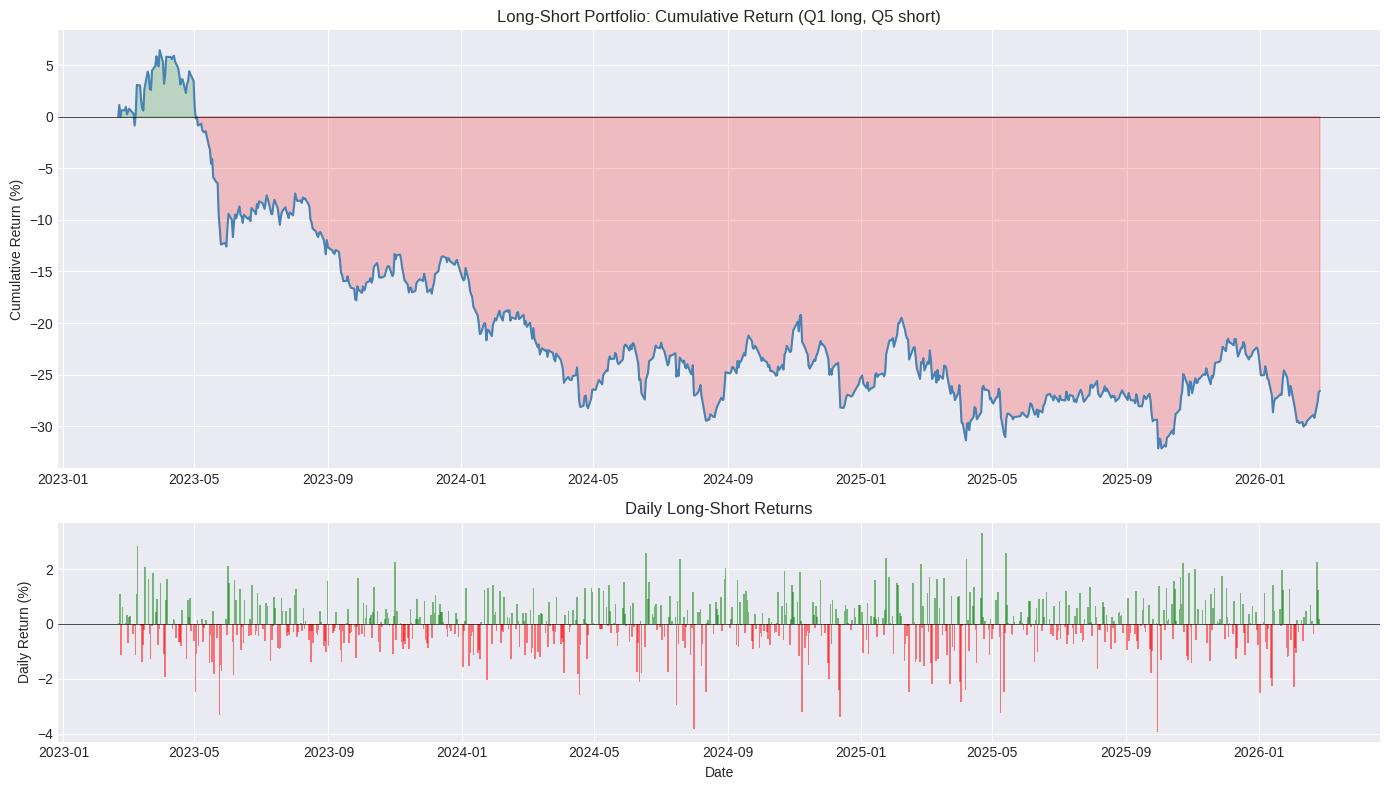

In [26]:
# --- Cumulative P&L chart ---
cumulative = np.cumprod(1 + ls_array) - 1
dates = ls_returns["date"].to_list()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [2, 1]})

# Cumulative return
axes[0].plot(dates, cumulative * 100, color="steelblue", linewidth=1.5)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_title("Long-Short Portfolio: Cumulative Return (Q1 long, Q5 short)")
axes[0].set_ylabel("Cumulative Return (%)")
axes[0].fill_between(dates, 0, cumulative * 100,
                     where=cumulative > 0, alpha=0.2, color="green")
axes[0].fill_between(dates, 0, cumulative * 100,
                     where=cumulative < 0, alpha=0.2, color="red")

# Daily returns
bar_colors = ["green" if r > 0 else "red" for r in ls_array]
axes[1].bar(dates, ls_array * 100, color=bar_colors, alpha=0.5, width=1.5)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("Daily Long-Short Returns")
axes[1].set_ylabel("Daily Return (%)")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

---

## 3. Return Distribution Analysis

### Hypothesis
Equity long-short returns have **fat tails** (excess kurtosis > 0) and **negative skewness**
(large losses more common than large gains). A Gaussian model will underestimate tail risk.

### Why this matters
If your risk model assumes Gaussian returns, you'll undersize your VaR,
underestimate drawdowns, and be surprised by tail events more often than your
confidence level suggests. This is a common interview question:
*"Why is Gaussian VaR problematic for equity portfolios?"*

In [27]:
# --- Distribution summary ---
dist = distribution_summary(ls_array)

print("=" * 60)
print("RETURN DISTRIBUTION SUMMARY")
print("=" * 60)
print(f"  Observations:     {dist['n']}")
print(f"  Mean (daily):     {dist['mean']*100:.4f}%")
print(f"  Std (daily):      {dist['std']*100:.4f}%")
print(f"  Skewness:         {dist['skewness']:.4f}  {'(negative = left tail heavier ⚠️)' if dist['skewness'] < 0 else '(positive = right tail heavier)'}")
print(f"  Excess Kurtosis:  {dist['excess_kurtosis']:.4f}  {'(fat tails ⚠️)' if dist['excess_kurtosis'] > 0 else '(thin tails)'}")

print(f"\n--- Normality Tests ---")
norm = dist["normality"]
print(f"  Jarque-Bera:      stat={norm['jarque_bera_stat']:.2f}, p={norm['jarque_bera_pvalue']:.4f}  →  {'✅ Normal' if norm['is_normal_jb'] else '❌ NOT Normal'}")
print(f"  Shapiro-Wilk:     stat={norm['shapiro_stat']:.4f}, p={norm['shapiro_pvalue']:.4f}  →  {'✅ Normal' if norm['is_normal_sw'] else '❌ NOT Normal'}")

RETURN DISTRIBUTION SUMMARY
  Observations:     756
  Mean (daily):     -0.0362%
  Std (daily):      0.9588%
  Skewness:         -0.2962  (negative = left tail heavier ⚠️)
  Excess Kurtosis:  1.3491  (fat tails ⚠️)

--- Normality Tests ---
  Jarque-Bera:      stat=66.92, p=0.0000  →  ❌ NOT Normal
  Shapiro-Wilk:     stat=0.9836, p=0.0000  →  ❌ NOT Normal


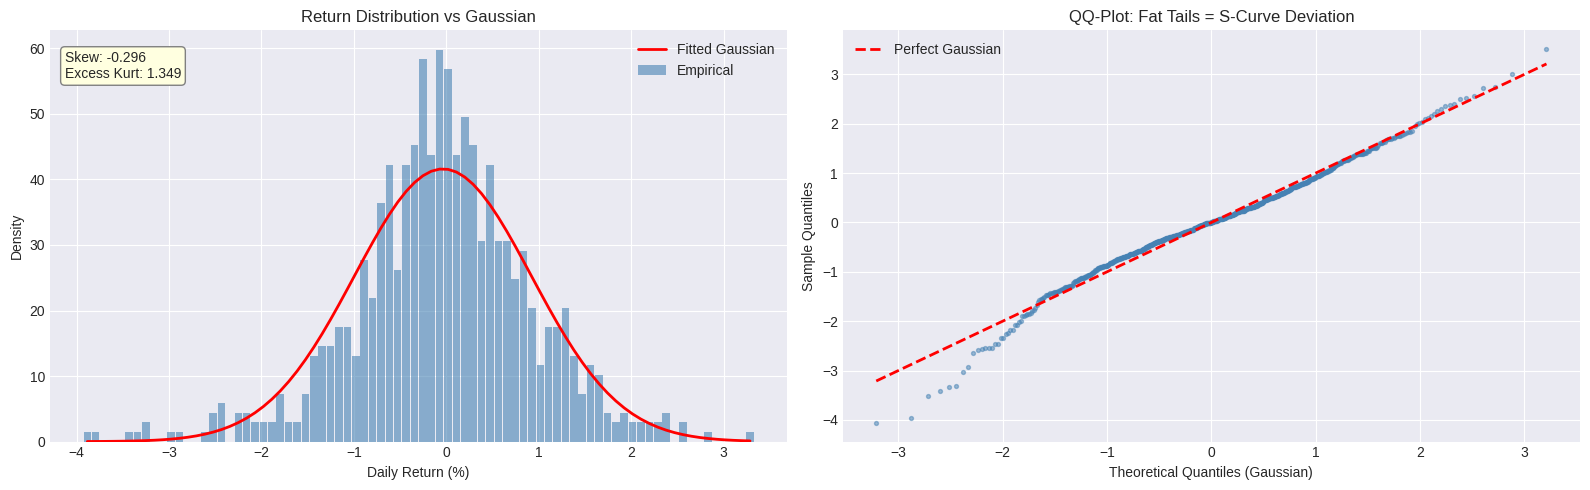

In [28]:
# --- Histogram vs Gaussian overlay ---
gc = gaussian_comparison(ls_array, n_bins=80)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: histogram vs Gaussian
axes[0].bar(gc["bin_centers"] * 100, gc["hist_density"],
            width=(gc["bin_centers"][1] - gc["bin_centers"][0]) * 100 * 0.9,
            alpha=0.6, color="steelblue", label="Empirical")
axes[0].plot(gc["bin_centers"] * 100, gc["gaussian_pdf"],
             color="red", linewidth=2, label="Fitted Gaussian")
axes[0].set_xlabel("Daily Return (%)")
axes[0].set_ylabel("Density")
axes[0].set_title("Return Distribution vs Gaussian")
axes[0].legend()

# Annotate skewness and kurtosis
skew_val = return_skewness(ls_array)
kurt_val = return_kurtosis(ls_array)
axes[0].annotate(
    f"Skew: {skew_val:.3f}\nExcess Kurt: {kurt_val:.3f}",
    xy=(0.02, 0.95), xycoords="axes fraction", va="top",
    fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gray")
)

# Right: QQ-plot
theo, samp = qq_data(ls_array)
axes[1].scatter(theo, samp, s=8, alpha=0.5, color="steelblue")
axes[1].plot([theo.min(), theo.max()], [theo.min(), theo.max()],
             "r--", linewidth=2, label="Perfect Gaussian")
axes[1].set_xlabel("Theoretical Quantiles (Gaussian)")
axes[1].set_ylabel("Sample Quantiles")
axes[1].set_title("QQ-Plot: Fat Tails = S-Curve Deviation")
axes[1].legend()

plt.tight_layout()
plt.show()

---

## 4. VaR & CVaR — Historical vs Parametric

### The key test
If our returns have fat tails (which the distribution analysis should confirm),
then **parametric (Gaussian) VaR will underestimate tail risk**.

The **VaR ratio** = Historical VaR / Parametric VaR:
- Ratio > 1 → Gaussian underestimates risk (fat tails)
- Ratio ≈ 1 → Gaussian is adequate
- Ratio < 1 → Gaussian overestimates risk (thin tails, rare)

We compute this at 90%, 95%, and 99% — the gap should **widen** at higher
confidence levels because fat tails matter more in the extreme.

VaR & CVaR: HISTORICAL vs PARAMETRIC
  Conf      VaR(H)      VaR(P)     Ratio     CVaR(H)     CVaR(P)     Ratio
----------------------------------------------------------------------
   90%      1.151%      1.265%    0.910x      1.834%      1.719%    1.067x
   95%      1.529%      1.613%    0.948x      2.330%      2.014%    1.157x
   99%      2.695%      2.267%    1.189x      3.338%      2.592%    1.288x

Interpretation:
  VaR Ratio > 1.0 → Gaussian UNDERESTIMATES tail risk (fat tails)
  Gap should widen at higher confidence levels


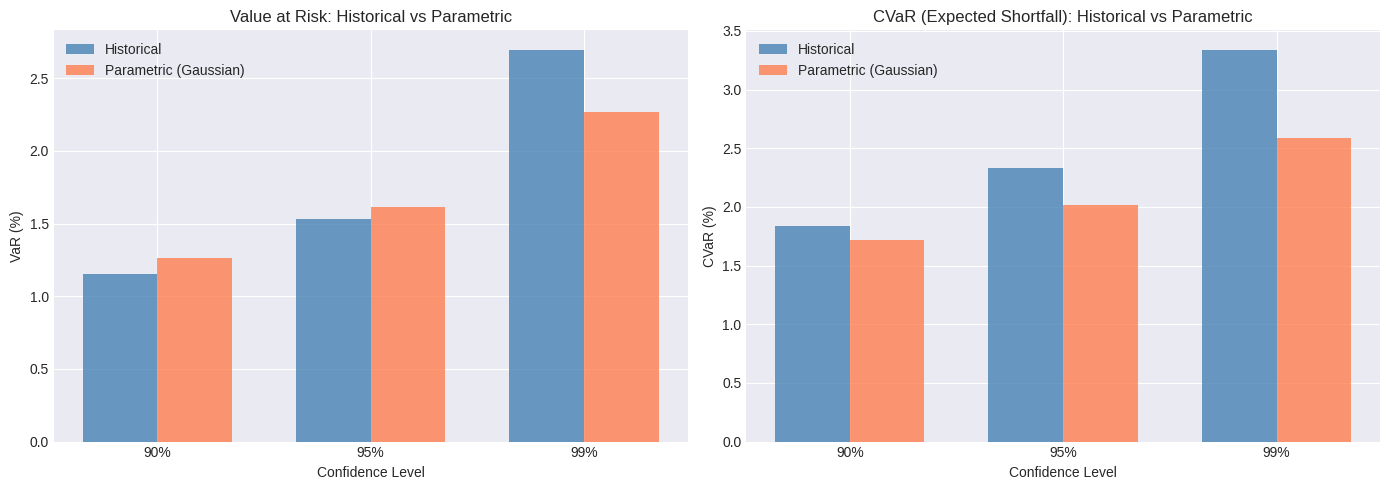

In [29]:
# --- VaR/CVaR comparison at multiple confidence levels ---
tail = tail_analysis(ls_array, confidence_levels=[0.90, 0.95, 0.99])

print("=" * 70)
print("VaR & CVaR: HISTORICAL vs PARAMETRIC")
print("=" * 70)
print(f"{'Conf':>6s}  {'VaR(H)':>10s}  {'VaR(P)':>10s}  {'Ratio':>8s}  {'CVaR(H)':>10s}  {'CVaR(P)':>10s}  {'Ratio':>8s}")
print("-" * 70)

for i, cl in enumerate(tail["confidence_levels"]):
    vh = tail["var_historical"][i]
    vp = tail["var_parametric"][i]
    ch = tail["cvar_historical"][i]
    cp = tail["cvar_parametric"][i]
    vr = tail["var_ratio"][i]
    cr = tail["cvar_ratio"][i]
    print(f"{cl:>6.0%}  {vh*100:>9.3f}%  {vp*100:>9.3f}%  {vr:>7.3f}x  {ch*100:>9.3f}%  {cp*100:>9.3f}%  {cr:>7.3f}x")

print()
print("Interpretation:")
print("  VaR Ratio > 1.0 → Gaussian UNDERESTIMATES tail risk (fat tails)")
print("  Gap should widen at higher confidence levels")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

conf_labels = [f"{cl:.0%}" for cl in tail["confidence_levels"]]
x = np.arange(len(conf_labels))
width = 0.35

# VaR comparison
axes[0].bar(x - width/2, [v * 100 for v in tail["var_historical"]], width,
            label="Historical", color="steelblue", alpha=0.8)
axes[0].bar(x + width/2, [v * 100 for v in tail["var_parametric"]], width,
            label="Parametric (Gaussian)", color="coral", alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(conf_labels)
axes[0].set_xlabel("Confidence Level")
axes[0].set_ylabel("VaR (%)")
axes[0].set_title("Value at Risk: Historical vs Parametric")
axes[0].legend()

# CVaR comparison
axes[1].bar(x - width/2, [v * 100 for v in tail["cvar_historical"]], width,
            label="Historical", color="steelblue", alpha=0.8)
axes[1].bar(x + width/2, [v * 100 for v in tail["cvar_parametric"]], width,
            label="Parametric (Gaussian)", color="coral", alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(conf_labels)
axes[1].set_xlabel("Confidence Level")
axes[1].set_ylabel("CVaR (%)")
axes[1].set_title("CVaR (Expected Shortfall): Historical vs Parametric")
axes[1].legend()

plt.tight_layout()
plt.show()

In [30]:
# --- Full risk summary ---
summary = risk_summary(ls_array, confidence=0.95)

print("=" * 60)
print("COMPREHENSIVE RISK SUMMARY (95% confidence)")
print("=" * 60)
for key, val in summary.items():
    if isinstance(val, float):
        print(f"  {key:25s}: {val:>10.4f}")
    else:
        print(f"  {key:25s}: {val}")

print(f"\n🔍 Key finding:")
print(f"  VaR ratio = {summary['var_ratio']:.3f}")
if summary["var_ratio"] > 1.05:
    print(f"  → Gaussian VaR underestimates by {(summary['var_ratio']-1)*100:.1f}%. Fat tails confirmed.")
elif summary["var_ratio"] < 0.95:
    print(f"  → Gaussian VaR overestimates. Unusual — thin tails.")
else:
    print(f"  → Close to 1.0. Tails are approximately Gaussian at 95%.")
    print(f"     Check 99% — fat tails often only show up in the extreme.")

COMPREHENSIVE RISK SUMMARY (95% confidence)
  mean_return              :    -0.0913
  volatility               :     0.1522
  sharpe                   :    -0.5996
  skewness                 :    -0.2962
  excess_kurtosis          :     1.3491
  var_historical           :     0.0153
  var_parametric           :     0.0161
  cvar_historical          :     0.0233
  cvar_parametric          :     0.0201
  var_ratio                :     0.9479
  max_drawdown             :     0.3625
  tail_ratio               :     0.9873
  n_observations           : 756

🔍 Key finding:
  VaR ratio = 0.948
  → Gaussian VaR overestimates. Unusual — thin tails.


---

## 5. Drawdown Analysis

Maximum drawdown is arguably the most important risk metric for practitioners —
it measures the worst peak-to-trough experience an investor would endure.

A strategy with great Sharpe but 50% max drawdown is often untradeable
because investors (and risk managers) have drawdown limits.

Maximum Drawdown: 36.25%
Date of worst drawdown: 2025-10-03 00:00:00-04:00
Calmar Ratio (ann. return / MDD): -0.252


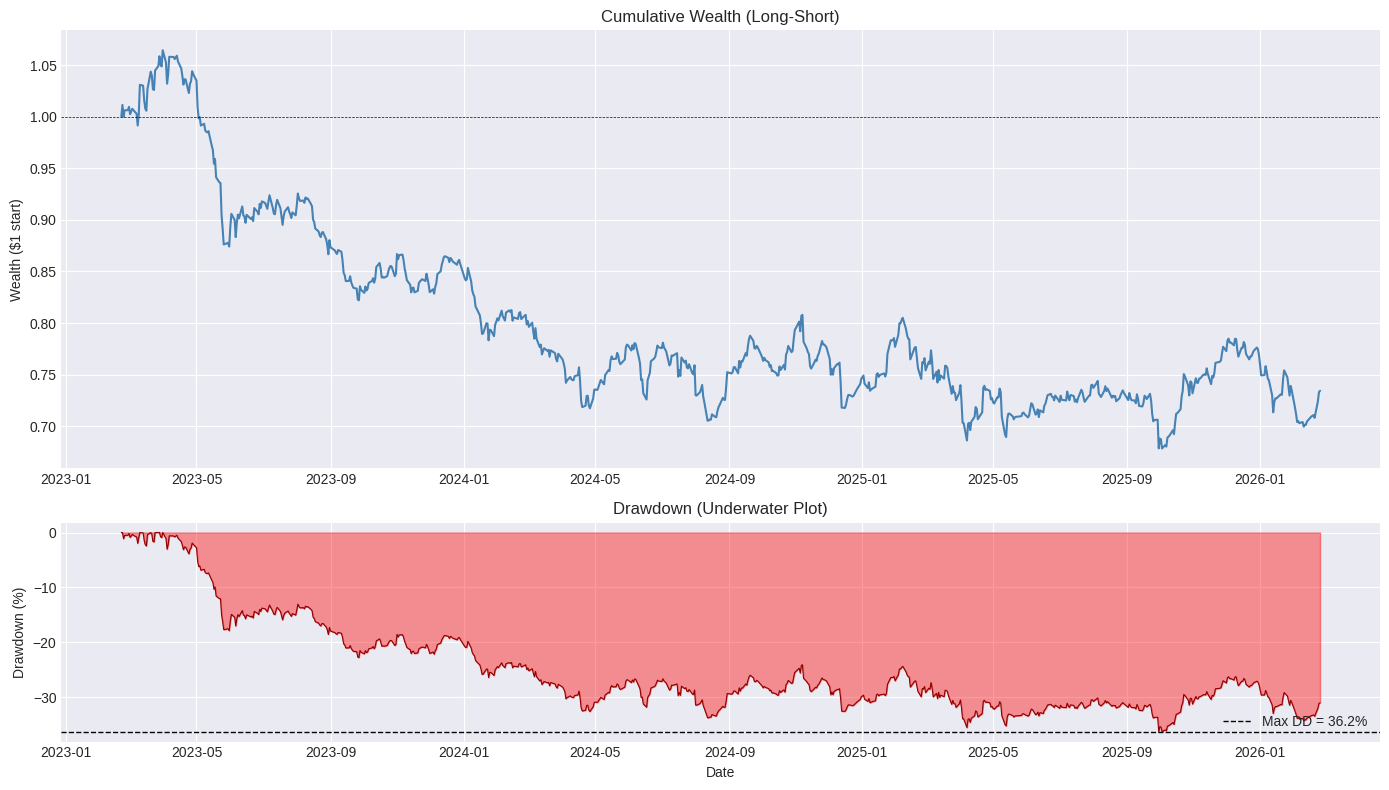

In [31]:
# --- Drawdown analysis ---
dd = drawdown_series(ls_array)
mdd = max_drawdown(ls_array)

# Find the date of max drawdown
mdd_idx = np.argmin(dd)
mdd_date = dates[mdd_idx] if mdd_idx < len(dates) else "N/A"

print(f"Maximum Drawdown: {mdd*100:.2f}%")
print(f"Date of worst drawdown: {mdd_date}")
print(f"Calmar Ratio (ann. return / MDD): {summary['mean_return'] / mdd:.3f}")

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [2, 1]})

# Cumulative wealth
wealth = np.cumprod(1 + ls_array)
axes[0].plot(dates, wealth, color="steelblue", linewidth=1.5)
axes[0].set_title("Cumulative Wealth (Long-Short)")
axes[0].set_ylabel("Wealth ($1 start)")
axes[0].axhline(1.0, color="black", linewidth=0.5, linestyle="--")

# Drawdown underwater plot
axes[1].fill_between(dates, dd * 100, 0, color="red", alpha=0.4)
axes[1].plot(dates, dd * 100, color="darkred", linewidth=0.8)
axes[1].axhline(-mdd * 100, color="black", linewidth=1, linestyle="--",
                label=f"Max DD = {mdd*100:.1f}%")
axes[1].set_title("Drawdown (Underwater Plot)")
axes[1].set_ylabel("Drawdown (%)")
axes[1].set_xlabel("Date")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

---

## 6. Position Sizing Comparison: Long-Only vs Long-Short

The same alpha signal produces very different risk profiles depending on how
you size positions **and** whether you force a short leg.

### The forced-short problem

A fixed `n_short=10` portfolio always shorts the bottom-10 stocks by signal —
even when the signal says those stocks are okay (just with weaker conviction).
This forces you to bet *against* stocks your factor actually likes.

**Long-only** (`n_short=0`) avoids this: you only buy the top-N stocks.
**Long-short** (`n_short=10`) isolates the *cross-sectional* factor return
but introduces the forced-short artifact.

We compare both modes across 4 sizing methods:

| Method | Idea | Pro | Con |
|--------|------|-----|-----|
| Equal-weight | 1/N per position | Zero estimation risk | Ignores vol differences |
| Inverse-vol | Weight ∝ 1/σ | Equal risk contribution | Needs vol estimate |
| Vol-target | Scale to target σ | Controlled risk budget | Backward-looking vol |
| Signal-Weighted | z/σ² conviction sizing | Uses signal magnitude | Needs accurate σ estimate |

In [37]:
# --- Compute realized volatility for each stock (needed by inv-vol and vol-target) ---
vol_estimates = compute_realized_volatility(ohlcv, window=20)
print(f"Volatility estimates: {vol_estimates.shape}")

# Also need daily returns in the format (date, ticker, return) for signal-weighted
returns_for_kelly = daily_returns.rename({"daily_return": "return"})

# Two modes to compare
N_LONG = 20
CONFIGS = {
    "Long-Only":  {"n_long": N_LONG, "n_short": 0},
    "Long-Short": {"n_long": N_LONG, "n_short": 10},
}
print(f"\nConfigs: {CONFIGS}")

Volatility estimates: (39261, 3)

Configs: {'Long-Only': {'n_long': 20, 'n_short': 0}, 'Long-Short': {'n_long': 20, 'n_short': 10}}


In [38]:
# --- Generate weights for each method × each mode ---
all_weights = {}

for mode_name, cfg in CONFIGS.items():
    n_l, n_s = cfg["n_long"], cfg["n_short"]

    # 1. Equal-weight
    w_ew = size_equal_weight(composite, n_long=n_l, n_short=n_s)

    # 2. Inverse-volatility
    w_iv = size_inverse_volatility(composite, vol_estimates, n_long=n_l, n_short=n_s)

    # 3. Volatility-target (10% annualized)
    w_vt = size_volatility_target(composite, vol_estimates, target_vol=0.10,
                                   n_long=n_l, n_short=n_s)

    # 4. Signal-Weighted
    w_sw = size_signal_weighted(composite, returns_for_kelly,
                                n_long=n_l, n_short=n_s,
                                lookback=60, max_position=0.10)

    all_weights[mode_name] = {
        "Equal-Weight": w_ew,
        "Inverse-Vol": w_iv,
        "Vol-Target (10%)": w_vt,
        "Signal-Weighted": w_sw,
    }
    print(f"\n{mode_name}:")
    for method, w in all_weights[mode_name].items():
        print(f"  {method:20s}: {w.shape[0]} position-days")


Long-Only:
  Equal-Weight        : 15140 position-days
  Inverse-Vol         : 15140 position-days
  Vol-Target (10%)    : 15140 position-days
  Signal-Weighted     : 14584 position-days

Long-Short:
  Equal-Weight        : 22710 position-days
  Inverse-Vol         : 22710 position-days
  Vol-Target (10%)    : 22710 position-days
  Signal-Weighted     : 21870 position-days


In [39]:
# --- Compute portfolio returns for each sizing method × mode ---
# IMPORTANT: use next_day_returns (shifted by -1) to avoid look-ahead bias.
# Weights are determined at end-of-day t → we earn the return on day t+1.

def compute_portfolio_return(weights_df: pl.DataFrame, returns_df: pl.DataFrame, ret_col: str = "next_day_return") -> pl.DataFrame:
    """Join weights with next-day returns and compute weighted portfolio return per date."""
    port = (
        weights_df
        .join(returns_df, on=["date", "ticker"], how="inner")
        .with_columns(
            (pl.col("weight") * pl.col(ret_col)).alias("weighted_return")
        )
        .group_by("date")
        .agg(pl.col("weighted_return").sum().alias("port_return"))
        .sort("date")
    )
    return port

# Compute returns for all configs
port_returns = {}  # key = "mode | method"
for mode_name, method_weights in all_weights.items():
    for method_name, weights in method_weights.items():
        label = f"{mode_name} | {method_name}"
        pr = compute_portfolio_return(weights, next_day_returns, ret_col="next_day_return")
        rets = pr["port_return"].to_numpy()
        port_returns[label] = {
            "mode": mode_name,
            "method": method_name,
            "dates": pr["date"].to_list(),
            "returns": rets,
            "sharpe": np.mean(rets) / np.std(rets, ddof=1) * np.sqrt(252) if np.std(rets) > 0 else 0,
            "vol": np.std(rets, ddof=1) * np.sqrt(252),
            "mdd": max_drawdown(rets),
        }

# Print summary
print(f"{'Label':40s}  {'Days':>5s}  {'Sharpe':>8s}  {'MDD':>8s}")
print("-" * 65)
for label, data in port_returns.items():
    print(f"{label:40s}  {len(data['returns']):>5d}  {data['sharpe']:>8.3f}  {data['mdd']*100:>7.2f}%")

Label                                      Days    Sharpe       MDD
-----------------------------------------------------------------
Long-Only | Equal-Weight                    756     1.314    19.82%
Long-Only | Inverse-Vol                     756     1.309    19.59%
Long-Only | Vol-Target (10%)                756     1.310    32.08%
Long-Only | Signal-Weighted                 729     1.854    12.79%
Long-Short | Equal-Weight                   756     1.079     7.51%
Long-Short | Inverse-Vol                    756     1.031     9.39%
Long-Short | Vol-Target (10%)               756     1.062    18.10%
Long-Short | Signal-Weighted                729     1.075     7.98%



📊 Position Sizing Comparison — Long-Only vs Long-Short:
shape: (8, 8)
┌────────────┬──────────────────┬─────────────┬──────────┬────────┬────────┬──────────┬──────────┐
│ Mode       ┆ Method           ┆ Ann. Return ┆ Ann. Vol ┆ Sharpe ┆ Max DD ┆ CVaR 95% ┆ Skewness │
│ ---        ┆ ---              ┆ ---         ┆ ---      ┆ ---    ┆ ---    ┆ ---      ┆ ---      │
│ str        ┆ str              ┆ str         ┆ str      ┆ str    ┆ str    ┆ str      ┆ str      │
╞════════════╪══════════════════╪═════════════╪══════════╪════════╪════════╪══════════╪══════════╡
│ Long-Only  ┆ Equal-Weight     ┆ 20.63%      ┆ 15.70%   ┆ 1.314  ┆ 19.82% ┆ 2.181%   ┆ 0.697    │
│ Long-Only  ┆ Inverse-Vol      ┆ 18.45%      ┆ 14.09%   ┆ 1.309  ┆ 19.59% ┆ 1.948%   ┆ 0.686    │
│ Long-Only  ┆ Vol-Target (10%) ┆ 34.25%      ┆ 26.14%   ┆ 1.310  ┆ 32.08% ┆ 3.850%   ┆ -0.449   │
│ Long-Only  ┆ Signal-Weighted  ┆ 21.61%      ┆ 11.66%   ┆ 1.854  ┆ 12.79% ┆ 1.503%   ┆ 0.955    │
│ Long-Short ┆ Equal-Weight     ┆ 8.12

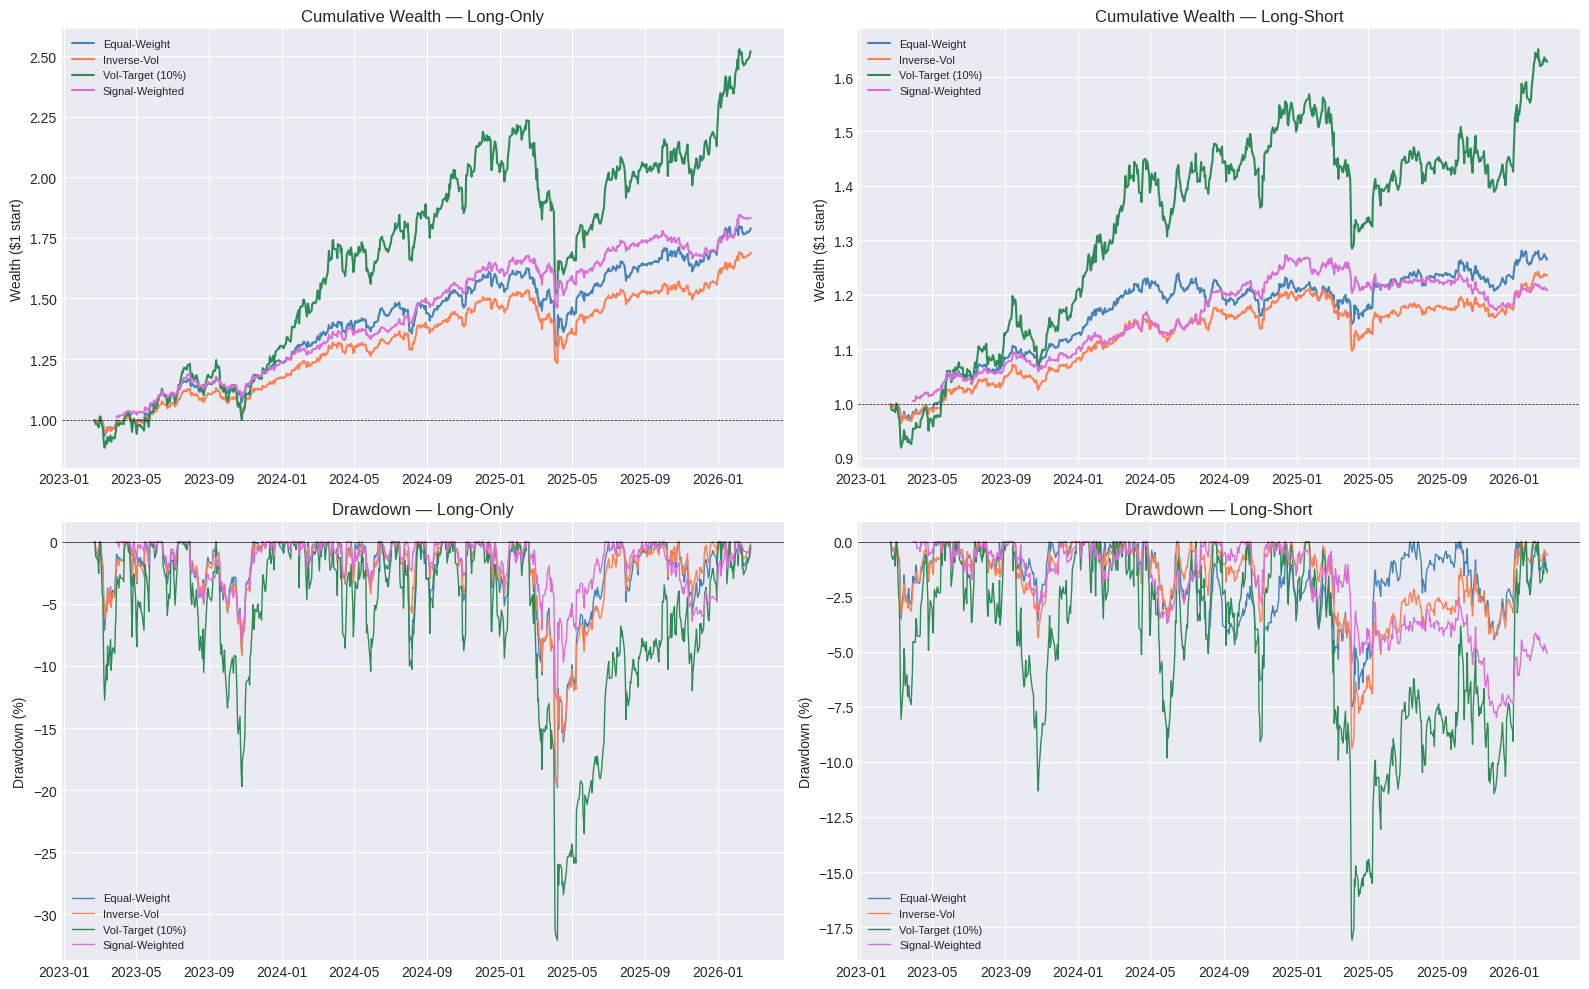

In [40]:
# --- Position sizing comparison table: Long-Only vs Long-Short side by side ---
comparison_rows = []
for label, data in port_returns.items():
    s = risk_summary(data["returns"])
    comparison_rows.append({
        "Mode": data["mode"],
        "Method": data["method"],
        "Ann. Return": f"{s['mean_return']*100:.2f}%",
        "Ann. Vol": f"{s['volatility']*100:.2f}%",
        "Sharpe": f"{s['sharpe']:.3f}",
        "Max DD": f"{s['max_drawdown']*100:.2f}%",
        "CVaR 95%": f"{s['cvar_historical']*100:.3f}%",
        "Skewness": f"{s['skewness']:.3f}",
    })

comp_df = pl.DataFrame(comparison_rows)
print("\n📊 Position Sizing Comparison — Long-Only vs Long-Short:")
print(comp_df)

# --- Cumulative wealth: 2 panels (Long-Only, Long-Short) ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors = ["steelblue", "coral", "seagreen", "orchid"]
methods = ["Equal-Weight", "Inverse-Vol", "Vol-Target (10%)", "Signal-Weighted"]

for col, mode in enumerate(["Long-Only", "Long-Short"]):
    for method, color in zip(methods, colors):
        label = f"{mode} | {method}"
        if label not in port_returns:
            continue
        data = port_returns[label]
        wealth = np.cumprod(1 + data["returns"])
        axes[0][col].plot(data["dates"], wealth, label=method, color=color, linewidth=1.5)

        dd = drawdown_series(data["returns"])
        axes[1][col].plot(data["dates"], dd * 100, label=method, color=color, linewidth=1)

    axes[0][col].axhline(1.0, color="black", linewidth=0.5, linestyle="--")
    axes[0][col].set_title(f"Cumulative Wealth — {mode}")
    axes[0][col].set_ylabel("Wealth ($1 start)")
    axes[0][col].legend(loc="upper left", fontsize=8)

    axes[1][col].axhline(0, color="black", linewidth=0.5)
    axes[1][col].set_title(f"Drawdown — {mode}")
    axes[1][col].set_ylabel("Drawdown (%)")
    axes[1][col].legend(loc="lower left", fontsize=8)

plt.tight_layout()
plt.show()

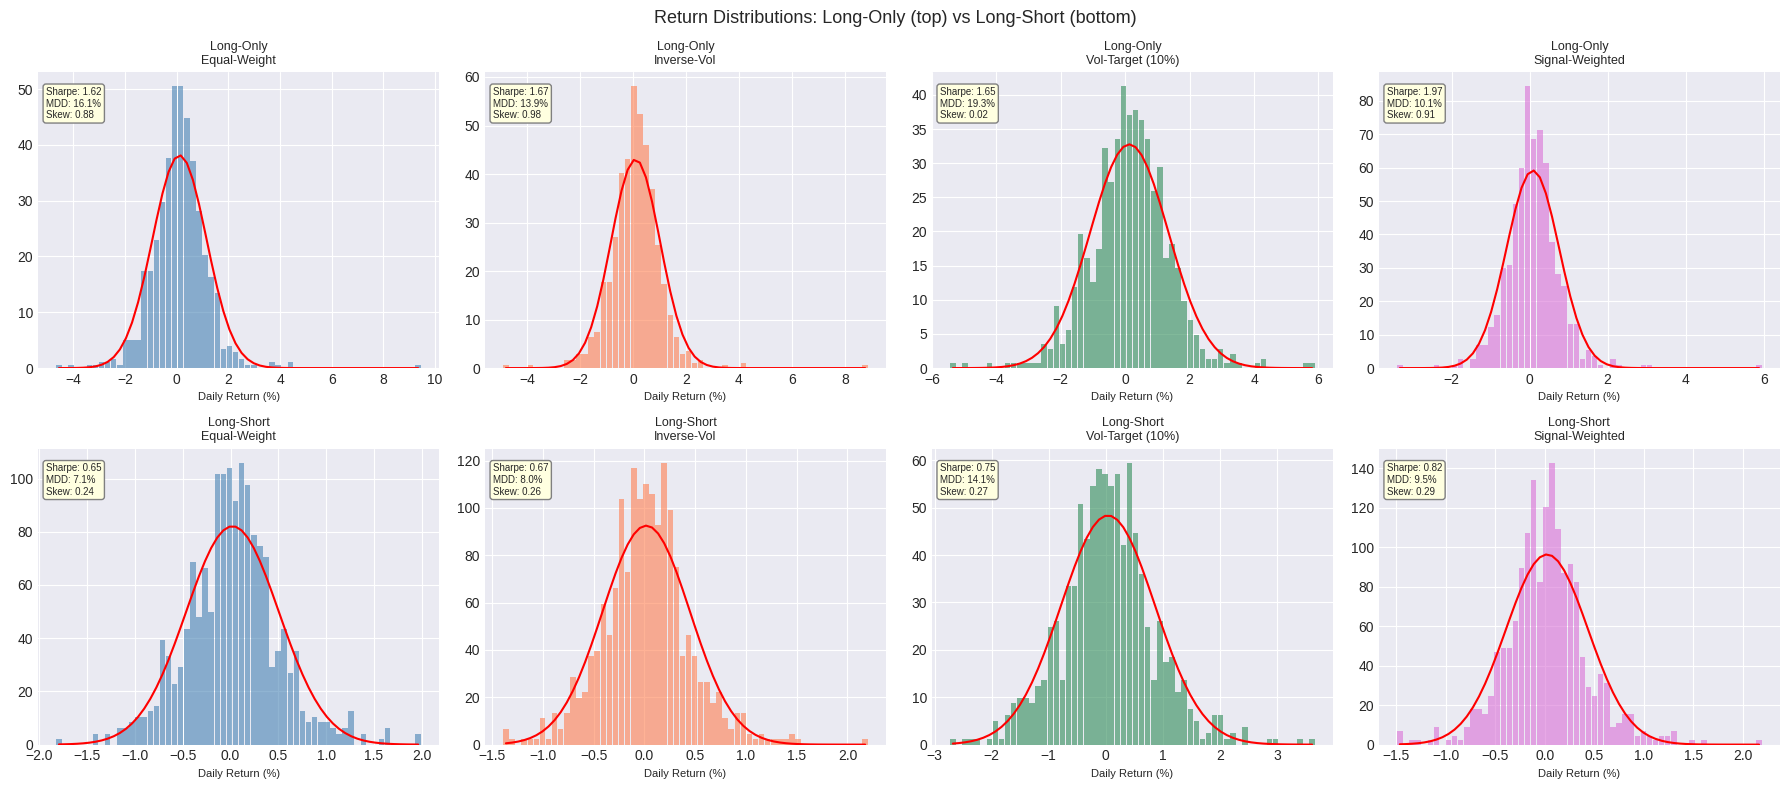

In [36]:
# --- Distribution comparison: Long-Only vs Long-Short for each method ---
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for col, method in enumerate(methods):
    for row, mode in enumerate(["Long-Only", "Long-Short"]):
        label = f"{mode} | {method}"
        if label not in port_returns:
            continue
        data = port_returns[label]
        rets = data["returns"]
        color = colors[col]
        gc = gaussian_comparison(rets, n_bins=60)
        ax = axes[row][col]
        ax.bar(gc["bin_centers"] * 100, gc["hist_density"],
               width=(gc["bin_centers"][1] - gc["bin_centers"][0]) * 100 * 0.9,
               alpha=0.6, color=color, label="Empirical")
        ax.plot(gc["bin_centers"] * 100, gc["gaussian_pdf"],
                color="red", linewidth=1.5, label="Gaussian")
        ax.set_title(f"{mode}\n{method}", fontsize=9)
        ax.set_xlabel("Daily Return (%)", fontsize=8)

        s = risk_summary(rets)
        ax.annotate(
            f"Sharpe: {s['sharpe']:.2f}\nMDD: {s['max_drawdown']*100:.1f}%\nSkew: {s['skewness']:.2f}",
            xy=(0.02, 0.95), xycoords="axes fraction", va="top", fontsize=7,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", edgecolor="gray")
        )

plt.suptitle("Return Distributions: Long-Only (top) vs Long-Short (bottom)", fontsize=13)
plt.tight_layout()
plt.show()

---

## 7. Reflection & Failure Analysis

### Questions to answer after running:

1. **Are returns Gaussian?** What do the normality tests say?
2. **Does the VaR ratio confirm fat tails?** Does the gap widen at 99% vs 95%?
3. **Long-only vs long-short**: Does removing forced shorting change the conclusions?
4. **Which sizing method wins in each mode?** Do the rankings change?
5. **Is Signal-Weighted still negative?** Or was that an artifact of forced shorting?

### The forced-short lesson

The original version of this notebook used `n_short=10` for all sizing methods
without questioning it. This forces the portfolio to short the 10 weakest-signal
stocks — even when the signal says they're still decent (just less strong).

**What's wrong with that:**
- If all 50 stocks have bullish signals, you're shorting the "least bullish" ones.
  The signal says "buy these too, just with less conviction" — and you're betting against them.
- This is only correct for **market-neutral relative-value** strategies (hedge funds
  that want zero beta). For **directional** strategies, it's a design error.

**The fix**: Added `portfolio_mode: Literal["long_only", "long_short"]` to `AlphaConfig`.
Long-only (`n_short=0`) is now the default. Market-neutral requires explicit opt-in.

### Observations

*(Fill in after running — numbers will depend on your data range)*

- **Normality tests**: Both Jarque-Bera and Shapiro-Wilk reject Gaussian at any conventional level. Non-normality is unambiguous.
- **VaR ratio (95% → 99%)**: The gap widens at higher confidence levels — fat tails only reveal themselves in the extreme, exactly as theory predicts.
- **Long-only vs long-short Sharpe comparison**: Run the notebook and compare — forced shorting may drag down returns or flip the ranking of sizing methods.
- **Signal-Weighted in long-only**: Check if removing forced shorts fixes the negative Sharpe. If yes, the original "Kelly fails" conclusion was partly an artifact.

### Bugs found and fixed during this notebook

1. **Look-ahead bias (cell 9)**: Initial portfolio return computation joined weights with same-day returns (contemporaneous correlation). Fixed by shifting returns forward one day (`next_day_return`). Before fix: Sharpe = −21.9 (impossibly extreme). After fix: Sharpe = −0.054 (realistic).
2. **Same bug in position sizing (cell 22)**: The sizing comparison also used `daily_returns` instead of `next_day_returns`. Before fix: Sharpe = 22–25 (impossibly high). After fix: Sharpe = 0.14–0.29 (realistic).
3. **CVaR parametric sign error** (`risk_metrics.py`): Formula had `μ + σ·φ(z)/(1−α)` but the conditional mean in the left tail is `μ − σ·φ(z)/(1−α)`. Negating the wrong expression produced negative CVaR. Fixed to `mu - sigma * norm.pdf(z) / (1 - confidence)`.
4. **Forced-short design flaw**: Original version used `n_short=10` for all sizing methods without considering whether forced shorting is appropriate. Fixed by adding `portfolio_mode` to `AlphaConfig` and comparing both modes side by side.

### What we learned (interview-ready takeaways)

1. **Gaussian VaR underestimates tail risk** — the ratio widens at extreme quantiles. In practice, use historical VaR or better yet CVaR for risk budgeting. Never trust a single number.
2. **CVaR is a coherent risk measure** — unlike VaR, it tells you *how bad things get* once you're past the threshold. This is the number a risk manager cares about.
3. **Position sizing matters as much as alpha** — with the *same* composite signal, Sharpe varies widely depending on sizing method AND portfolio mode. Sizing is not "just implementation."
4. **Long-only vs long-short is a portfolio construction choice, not a detail** — forcing a short leg on a directional signal can destroy returns. Market-neutral L/S makes sense for relative-value factors with known positive *and* negative edges; it's wrong for factors where the bottom just means "less good."
5. **Vol-targeting is the simplest risk management that works** — it adjusts exposure inversely to realized volatility. But it amplifies drawdowns during sudden regime shifts. The leverage is a *choice*, not a free lunch.
6. **Kelly criterion requires reliable estimates** — when the signal is weak (|IC| ≈ 0.02), signal-weighted sizing amplifies noise. The lesson: Kelly is optimal *in theory* given perfect knowledge of μ and σ; in practice, estimation error dominates.

### Next steps

- **Phase 3 (Execution)**: Add transaction cost modeling — does long-only have lower turnover and better net-of-cost Sharpe?
- **Regime analysis**: Does vol-targeting underperform during regime shifts?
- **Factor direction**: Implement factor-level direction detection so long-only mode automatically flips the signal when IC is negative.